In [33]:

import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from hdbscan import HDBSCAN
from pathlib import Path
from metric_learning.dataset import DataWithLabels

import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from torch.utils.data import Dataset, random_split, DataLoader
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR


In [34]:
dataset = DataWithLabels.from_npz(r'clustered_data/data_higher.npz')
# dataset.augument_randomly(ratio = 1.0, repetition=True)

X              = dataset.x
Values         = dataset.values
Configurations = dataset.configurations
Energies       = dataset.energies
Labels         = dataset.labels


## Contrastive Learning

In [35]:
from metric_learning.dataset import MetricLearningDataset, make_balanced_train_test_dataset

vectors = torch.from_numpy(X).float()
vectors = torch.nn.functional.normalize(vectors, dim=1)

sims = []
for i in range(len(vectors)):
    dot = torch.matmul(vectors[i], vectors.t()) # cos for all vectors with i-th vector
    sims.append(dot)

sims = torch.cat(sims) 
COS_MIN_GLOBAL = sims.min().item()
COS_MAX_GLOBAL = sims.max().item()


In [36]:
from metric_learning.losses import continuous_contrastive_loss, Q_distance, wms_loss
from functools import partial
from sklearn.metrics import pairwise_distances
from metric_learning.model import Embedder,TrainConfig, train_model, get_embeddings

save_dir = Path('models')
BATCH_SIZE = 128
NUM_EPOCHS = 200
LEARNING_RATE = 3e-4
EMBEDDING_SIZE = 3
# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader, test_loader = make_balanced_train_test_dataset(
                                Configurations, X, 
                                batch_size=BATCH_SIZE, 
                                train_ratio=0.8, 
                            )
train = True
save_model = True
if train:
    model = Embedder(embedding_size=EMBEDDING_SIZE).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    # warmup epochs
    warmup_epochs = max(1, int(0.05 * NUM_EPOCHS))
    sched1 = LinearLR(optimizer, start_factor=1e-2, end_factor=1.0, total_iters=warmup_epochs)
    sched2 = CosineAnnealingLR(optimizer, T_max=(NUM_EPOCHS - warmup_epochs))
    scheduler = SequentialLR(optimizer, schedulers=[sched1, sched2], milestones=[warmup_epochs])




    loss_function = partial(continuous_contrastive_loss,mu=1.0, ms_mining=True)
    # loss_function = partial(wms_loss,
    #                         d_alpha =5.0,
    #                         d_beta= 1.0,
    #                         alpha=10.0,
    #                         beta=1.0,
    #                         lamb=0.0,
    #                         eps=0.1,
    #                         sumfunction='ms')

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_function=loss_function,
        Q_distance=partial(Q_distance, c_min = COS_MIN_GLOBAL, c_max = COS_MAX_GLOBAL),
        train_loader=train_loader,
        test_loader=test_loader,
    )
    # Train the 


    avg_loss, avg_val_loss = train_model(config, num_epochs=NUM_EPOCHS)

    if save_model:
        torch.save({
            'model_state_dict': model.state_dict(),
            'embedding_size': EMBEDDING_SIZE,
        }, save_dir / 'embedder.pt')
else:
    checkpoint = torch.load(save_dir / 'embedder.pt', map_location=device, weights_only=True)

    model = Embedder(embedding_size=checkpoint['embedding_size']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=None,
        scheduler=None,
        train_loader=None,
        test_loader=None,
    )

# Get embeddings for all configurations
all_embeddings = get_embeddings(config, Configurations)
print(f"Embeddings shape: {all_embeddings.shape}")


Epoch 1/200, Average Loss: 0.173070, Average Val Loss: 0.170926
Epoch 2/200, Average Loss: 0.168208, Average Val Loss: 0.135750
Epoch 3/200, Average Loss: 0.156378, Average Val Loss: 0.136048
Epoch 4/200, Average Loss: 0.154273, Average Val Loss: 0.132846
Epoch 5/200, Average Loss: 0.150912, Average Val Loss: 0.130861
Epoch 6/200, Average Loss: 0.148030, Average Val Loss: 0.133172
Epoch 7/200, Average Loss: 0.144205, Average Val Loss: 0.126047
Epoch 8/200, Average Loss: 0.138492, Average Val Loss: 0.117857
Epoch 9/200, Average Loss: 0.132215, Average Val Loss: 0.115123
Epoch 10/200, Average Loss: 0.128498, Average Val Loss: 0.115286
Epoch 11/200, Average Loss: 0.123352, Average Val Loss: 0.108144
Epoch 12/200, Average Loss: 0.120360, Average Val Loss: 0.103606
Epoch 13/200, Average Loss: 0.117146, Average Val Loss: 0.100216
Epoch 14/200, Average Loss: 0.113397, Average Val Loss: 0.096649
Epoch 15/200, Average Loss: 0.111424, Average Val Loss: 0.095485
Epoch 16/200, Average Loss: 0.1079

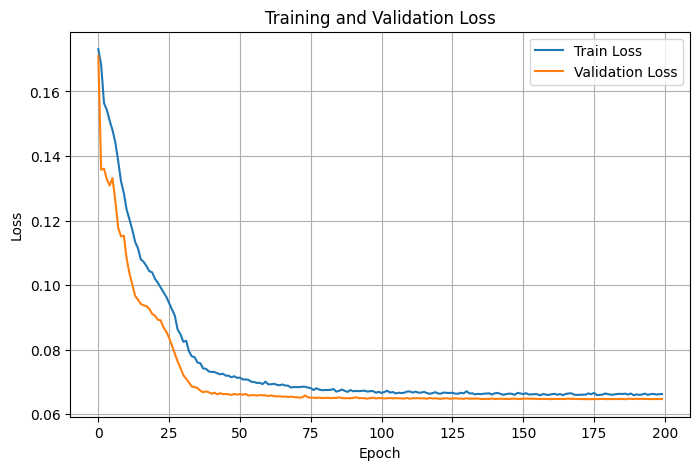

In [37]:
from metric_learning.utils import plot_loss_curves
if train:
    plot_loss_curves(avg_loss, avg_val_loss)

## Clustering

here, we shall cluster samples in the embedding space and compare to the original clustering.

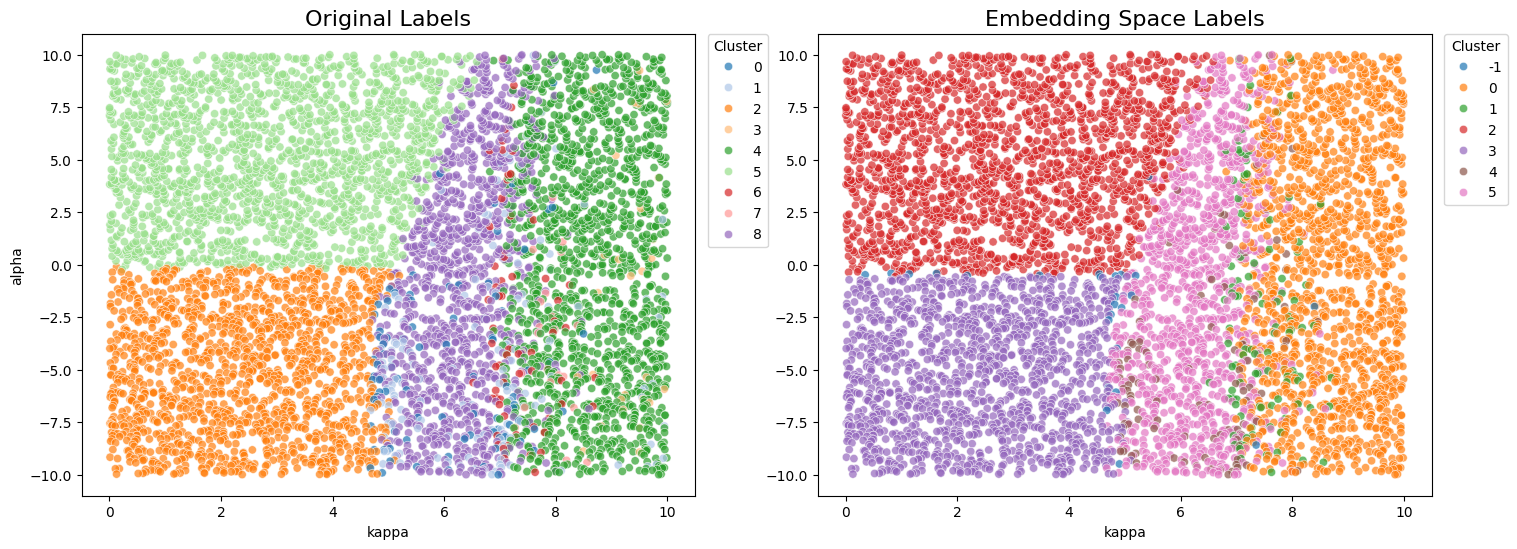

In [38]:
from metric_learning.utils import compare_clusterings

hd2 = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.018, cluster_selection_method='eom').fit(all_embeddings)
Labels2 = hd2.labels_

compare_clusterings(Values, Labels, Labels2)

In [39]:
unique_cl = np.unique(Labels2)
highest_prob = []
for i in unique_cl:
    probs = hd2.probabilities_.copy()
    probs[~(Labels2 == i)] = 0.0
    highest_prob.append(np.argmax(probs))

In [41]:
from metric_learning.utils import plot_2d_arrows_stratified, plot_3d_arrows_stratified

dim = all_embeddings.shape[-1]

if dim == 2:
    fig = plot_2d_arrows_stratified(all_embeddings, Labels2, samples_per_cluster=10000)
    fig.show()
elif dim == 3:
    fig = plot_3d_arrows_stratified(all_embeddings, Labels2, samples_per_cluster=400)
    fig.show()

In [42]:
from tqdm import tqdm
from metric_learning.utils import InteractivePhaseDiagram

GradFile = np.load('ConfigsSiamese.npz')
configs = GradFile['configs']
alpha_kappa = GradFile['values']
energies = GradFile['energies']


embeddings_opt = get_embeddings(config, configs)



    'data': [{'customdata': {'bdata': 'pgPJBgoTukj/Qh02+SNvMOUI1EiaDw4iHjL/PJcM8…

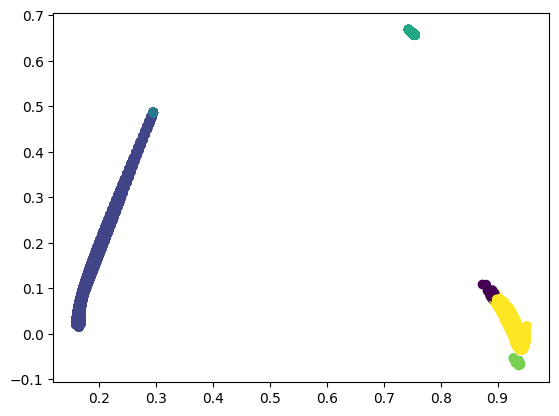

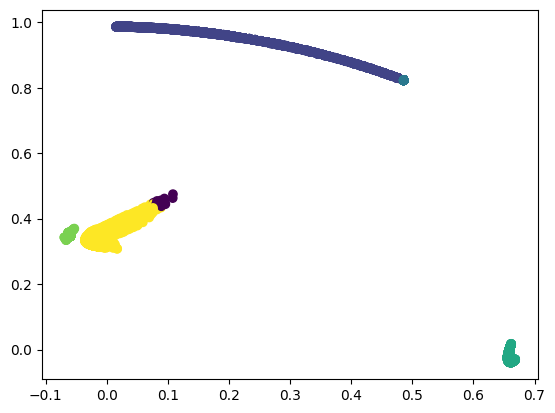

In [44]:
hd2 = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.01, cluster_selection_method='eom').fit(embeddings_opt)
Labels2_grad = hd2.labels_

data_current = DataWithLabels(
    configs,
    alpha_kappa, None, energies, Labels2_grad
)


InteractivePhaseDiagram(data_current).show()

plt.scatter(embeddings_opt[:,0], embeddings_opt[:, 1], c=Labels2_grad)
plt.show(), plt.close()
plt.scatter(embeddings_opt[:,1], embeddings_opt[:, 2], c=Labels2_grad)

In [45]:
fig = plot_3d_arrows_stratified(embeddings_opt, Labels2_grad, samples_per_cluster=400)
fig.show()

In [46]:
Values_opt         = alpha_kappa
Configurations_opt = configs
Energies_opt       = energies
X_opt             = np.empty_like(Labels2_grad)

embeddings_grad = embeddings_opt


data_w_new_labels_grad = DataWithLabels(
    configs, alpha_kappa, X_opt, energies,Labels2_grad
)

In [47]:
# save learned for graphing
dir = Path('results')
dir.mkdir(exist_ok=True)
save = True
if save:
    np.save(dir / 'embeddings.npy', all_embeddings)
    
    data_w_new_labels = DataWithLabels(
        Configurations,
        Values,
        X,
        Energies,
        Labels2,
    )

    data_w_new_labels.to_npz(dir / 'configs.npz')
    np.save(dir / 'embeddings.npy', all_embeddings  )
    data_w_new_labels_grad.to_npz(dir / 'configs_grad.npz')
    np.save(dir / 'embeddings_grad.npy', embeddings_grad)


In [ ]:
# init_conf_path = Path('init_conf/siamese')
# init_configs = np.array([np.load(f) for f in init_conf_path.iterdir()])

# data_init = DataWithLabels(
#     init_configs,
#     None,
#     None,
#     None,
#     np.ones(init_configs.shape[0]),
# )

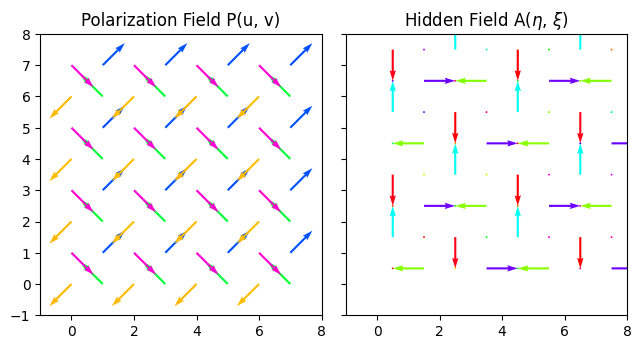

Cluster 1


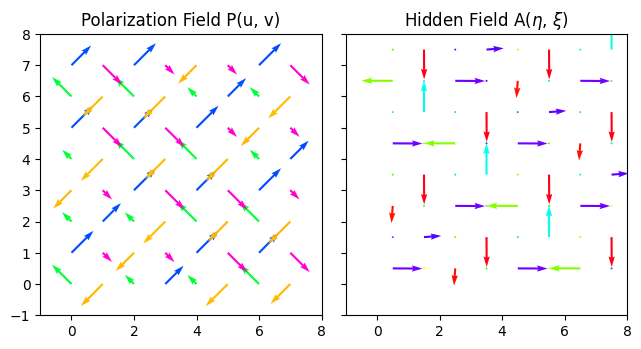

Cluster 2


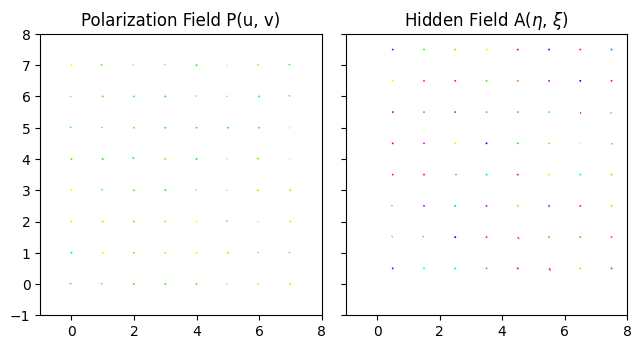

Cluster 3


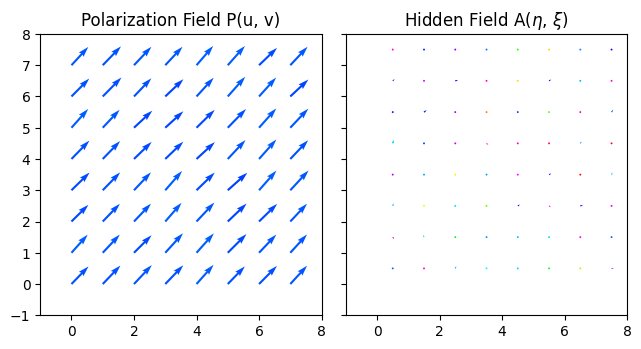

Cluster 4


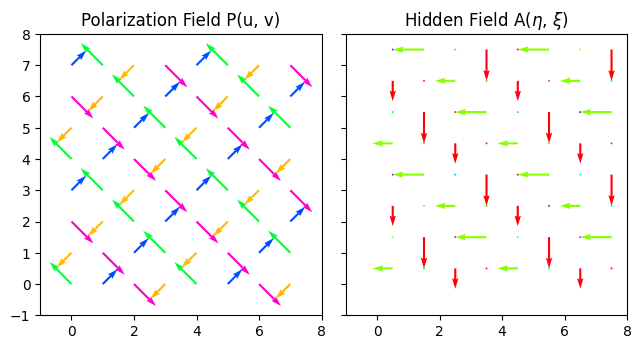

Cluster 5


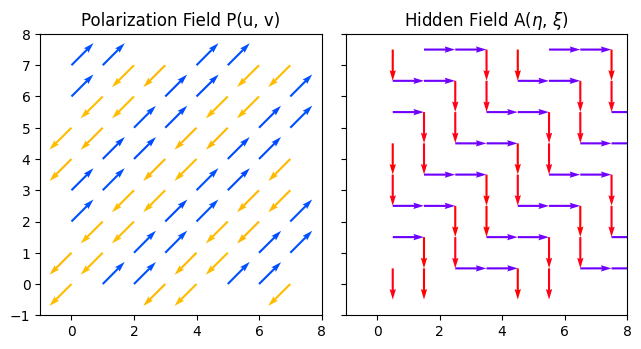

In [ ]:
# for cl, ind in zip(unique_cl, highest_prob):
#     if cl == -1:
#         continue
#     print(f'Cluster {cl}')
#     data_w_new_labels.plot(ind)

In [ ]:
# from sklearn.metrics import pairwise_distances

# def find_medoids(embeddings, labels):
#     res = {}
#     for label in np.unique(labels):
#         cluster_indices = np.where(labels == label)[0]
#         cluster_embeddings = embeddings[cluster_indices]
#         distances = pairwise_distances(cluster_embeddings)
#         medoid_in_cluster = np.argmin(distances.sum(axis=1))
#         medoid_global = cluster_indices[medoid_in_cluster]
#         res.update({label:medoid_global})
#     return res

# medoid_ind = find_medoids(all_embeddings, Labels2)

-1


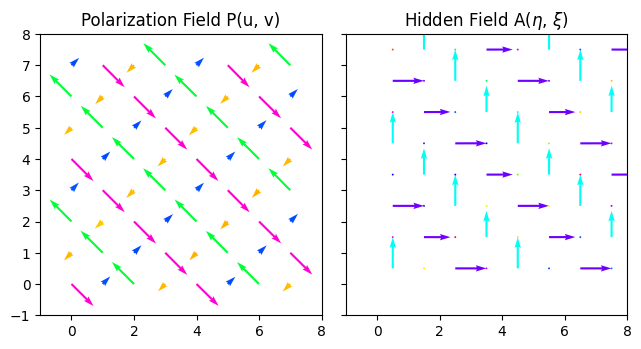

0


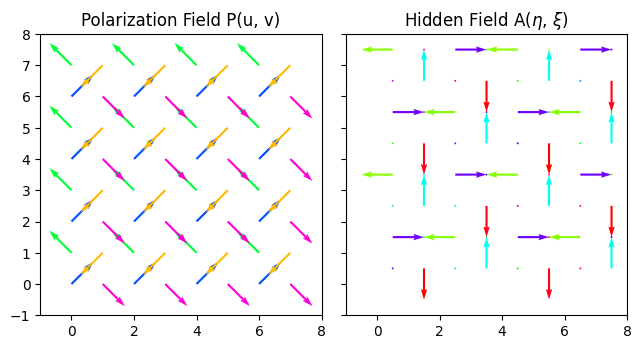

1


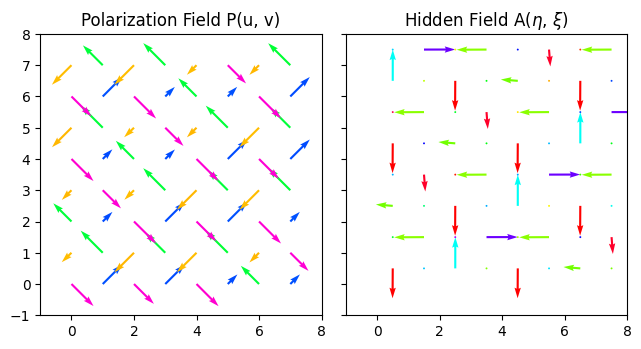

2


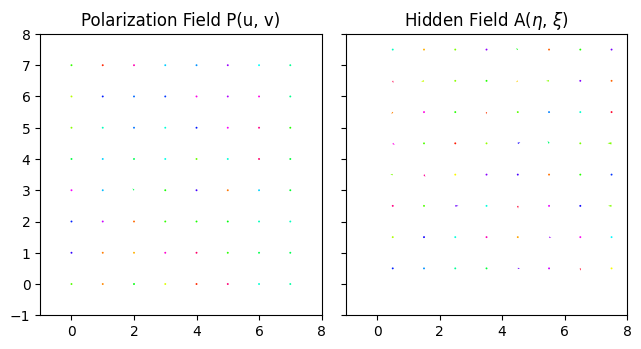

3


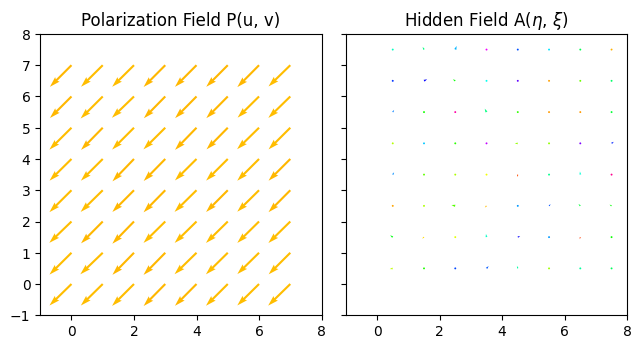

4


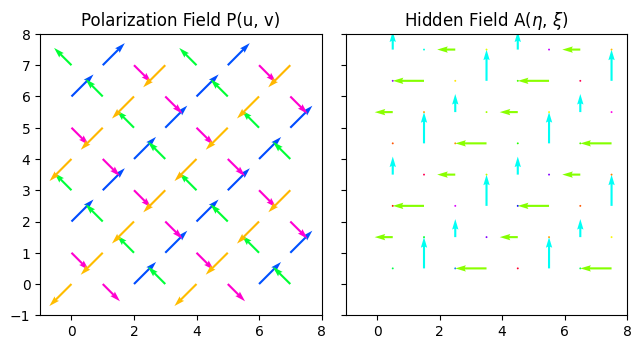

5


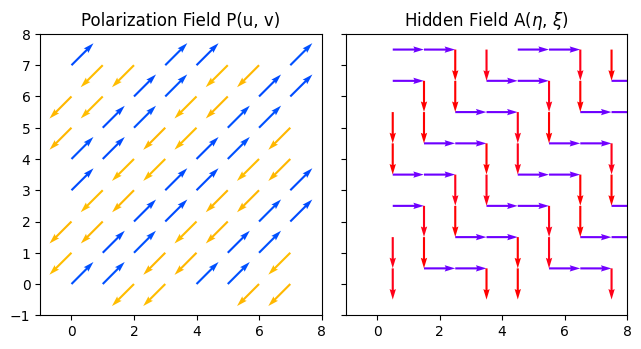

In [ ]:
# for cl, ind in medoid_ind.items():
#     print(cl)
#     data_w_new_labels.plot(ind)